# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dyajaballh8/FlyRank_Intern/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Capstone — Search Performance Signals for Content Prioritization

This notebook mirrors the deployed research paper for the FlyRank Machine Learning capstone.

The analysis studies whether observable Google Search Console (GSC) performance signals can help prioritize content items for human review when looking for possible CTR improvement opportunities.

The work is decision-support only. It does not claim that a content change will cause a specific CTR improvement.

# Abstract

Content teams often need to decide which pages should be reviewed first when search performance suggests a possible opportunity. This capstone investigates whether observable Google Search Console (GSC) signals can support that prioritization.

Using daily content-performance data from May 2026, the analysis focuses on GSC impressions, clicks, and average search position. A transparent rule is used as the baseline, while Logistic Regression is tested as a simple probabilistic ranking model. The target defines a CTR review opportunity as content with at least 500 impressions, an average position between 1 and 20, and CTR below 0.5%.

The evaluation uses a client-grouped holdout split so that clients in the test set are not used during training. On the evaluated split, the rule baseline achieved an F1 score of 1.0000, while Logistic Regression achieved an F1 score of 0.6584, with recall of 0.9908 and precision of 0.4930.

The results show that the transparent rule is stronger for reproducing the operational target because the target itself is defined from the same thresholds. The model therefore should be viewed as a prioritization and decision-support experiment rather than evidence of causal CTR improvement. Human review remains necessary before any content change is made.

# Introduction

## The content problem

Content teams cannot review every content item with the same level of attention. A practical workflow therefore needs a way to prioritize which items deserve investigation first.

The case study behind this analysis is a content-prioritization problem: identify search-performance patterns that may indicate that a content item deserves a closer CTR review.

The question is not whether a machine-learning model can "solve SEO" automatically. Instead, the goal is narrower and safer:

> Can observable search-performance signals help a content team decide which items should be reviewed first?

This framing connects the modeling work directly to a real content decision. The output is intended to support human prioritization, not to automatically rewrite content or claim that a specific change will improve search performance.

The analysis uses public-safe reporting language. Results are described as observed, measured, directional, and decision-support evidence.

## 1. Question

### Research Question

Can observable Google Search Console performance signals be used to identify content items that may deserve review for CTR improvement?

The decision supported by this analysis is content prioritization: which content items should be reviewed first based on observed search-performance signals.

This work is intended as decision-support. It does not claim that changing a title, snippet, or page will cause a specific CTR improvement.

In [4]:
# Section 1 — Research question check

research_question = (
    "Can observable GSC performance signals identify "
    "content items that may deserve CTR review?"
)

decision_supported = (
    "Prioritize content items for human review"
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

print("\nSection 1 check passed.")

Research question:
Can observable GSC performance signals identify content items that may deserve CTR review?

Decision supported:
Prioritize content items for human review

Section 1 check passed.


## 2. Data

This analysis uses the FlyRank ML Internship dataset and the May 2026 release of daily content performance data.

The main table used is:

`fact_content_daily_performance`

The analysis uses observable Google Search Console signals:

- GSC impressions
- GSC clicks
- GSC average position
- Report date

Only rows with available GSC data, positive impressions, and valid average position values are included.

Rows without usable GSC measurements are excluded because the model and baseline depend on these search-performance signals.

Client-identifying information is not included in the paper outputs.

The analysis is based on the available May 2026 data window used in the modeling notebooks.

In [5]:
# Section 2 — Data check

print("Dataset release: May 2026")
print("Main table: fact_content_daily_performance")

print("\nFeatures used:")
for feature in [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position"
]:
    print("✓", feature)

print("\nExclusions:")
print("✓ Rows without available GSC data")
print("✓ Rows with zero impressions")
print("✓ Rows with invalid average position")

print("\nSection 2 check passed.")

Dataset release: May 2026
Main table: fact_content_daily_performance

Features used:
✓ gsc_impressions
✓ gsc_clicks
✓ gsc_avg_position

Exclusions:
✓ Rows without available GSC data
✓ Rows with zero impressions
✓ Rows with invalid average position

Section 2 check passed.


## 3. Methodology

### Target definition

The target identifies a CTR improvement opportunity using the following rule:

- Impressions >= 500
- Average position between 1 and 20
- CTR < 0.5%

CTR is calculated as:

`clicks / impressions × 100`

A target value of `1` indicates that the item meets this operational definition. Otherwise the target is `0`.

### Model

Logistic Regression is used as the modeling method because the target is binary and the model produces probabilities that can be used for ranking.

The model uses:

- GSC impressions
- GSC clicks
- GSC average position

StandardScaler is applied before Logistic Regression.

Class weighting is used because the positive class is relatively uncommon.

### Baseline

The Week-4 rule baseline uses the same threshold definition:

- impressions >= 500
- average position <= 20
- CTR < 0.5%

The model and baseline are evaluated on the same holdout data.

### Validation design

The primary honest validation design groups rows by client.

This prevents the same client from appearing in both training and test sets.

This is preferable to a random row-level split because rows from the same client may share similar search-performance patterns.

### Leakage audit

The feature set was reviewed for variables that directly encode future outcomes or business decisions.

The final model uses observable GSC performance signals only.

However, the target is constructed from the same GSC signals used as features. Therefore, the measured model performance should be interpreted cautiously and should not be treated as evidence of causal CTR improvement.

In [6]:
# Section 3 — Methodology setup and target definition

FEATURES = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position"
]

TARGET_RULE = (
    "impressions >= 500 AND "
    "average position <= 20 AND "
    "CTR < 0.5%"
)

print("Model: Logistic Regression")

print("\nFeatures:")
for feature in FEATURES:
    print("✓", feature)

print("\nTarget:")
print(TARGET_RULE)

print("\nValidation:")
print("✓ Grouped by client")

print("\nLeakage audit:")
print("✓ No future-window feature used")
print("✓ No business decision flag used")
print("⚠ Target is derived from the same GSC signals")

print("\nSection 3 check passed.")

Model: Logistic Regression

Features:
✓ gsc_impressions
✓ gsc_clicks
✓ gsc_avg_position

Target:
impressions >= 500 AND average position <= 20 AND CTR < 0.5%

Validation:
✓ Grouped by client

Leakage audit:
✓ No future-window feature used
✓ No business decision flag used
⚠ Target is derived from the same GSC signals

Section 3 check passed.


## 4. Results (vs baseline)

The model and the Week-4 rule baseline were evaluated on the same grouped test split.

The observed results were:

| Method | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| Week-4 Rule Baseline | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| Logistic Regression | 0.9867 | 0.4930 | 0.9908 | 0.6584 |

The baseline measured higher classification performance because the target definition directly follows the same threshold rules used by the baseline.

The Logistic Regression model measured high recall (0.9908) but lower precision (0.4930), resulting in an F1 score of 0.6584.

These numbers are descriptive of the evaluated split. They should not be interpreted as evidence that the model causes CTR improvement.

In [7]:
# Section 4 — Results table

import pandas as pd

results = pd.DataFrame({
    "Method": [
        "Week-4 Rule Baseline",
        "Logistic Regression"
    ],
    "Accuracy": [
        1.0000,
        0.9867
    ],
    "Precision": [
        1.0000,
        0.4930
    ],
    "Recall": [
        1.0000,
        0.9908
    ],
    "F1": [
        1.0000,
        0.6584
    ]
})

display(results.round(4))

print("\nSection 4 check passed.")

,Method,Accuracy,Precision,Recall,F1
0,Week-4 Rule Baseline,1.0000,1.000,1.0000,1.0000
1,Logistic Regression,0.9867,0.493,0.9908,0.6584



Section 4 check passed.


## 5. Limitations

This analysis has several important limitations.

First, the target is defined directly from GSC impressions, average position, and CTR, while these same signals are used as model features. This creates a strong dependency between the target definition and the input features.

Second, the analysis is observational. It measures associations in search-performance data and does not establish that a recommended content change will cause CTR improvement.

Third, the evaluation reflects the available data window and grouped validation design. Performance may differ on future data, different clients, or different search environments.

Fourth, the Logistic Regression model produces prioritization signals but does not understand the full editorial, business, or search-intent context of a page.

Therefore, the results should be described as observed, measured, directional, and decision-support evidence rather than causal or guaranteed outcomes.

In [8]:
# Section 5 — Limitations checklist

limitations = [
    "Target is derived from the same GSC signals used as features",
    "Analysis is observational",
    "Results depend on the available data window",
    "Performance may differ on future or different data",
    "Model does not capture full editorial or business context",
    "Recommendations require human review"
]

for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")

assert len(limitations) >= 5

print("\nSection 5 check passed.")

1. Target is derived from the same GSC signals used as features
2. Analysis is observational
3. Results depend on the available data window
4. Performance may differ on future or different data
5. Model does not capture full editorial or business context
6. Recommendations require human review

Section 5 check passed.


## 6. Ranked recommendations

## 6. Ranked recommendations

The action playbook converts observed search-performance signals into a ranked review queue.

The recommendations are intended to help a content reviewer decide where to investigate first.

### Priority 1 — High

**Reason code:** `HIGH_IMPRESSIONS_LOW_CTR`

Content with relatively high impressions, good search position, and CTR below the defined threshold should receive early review.

**Recommended action:**
Review the title and search snippet and verify that they match the search intent.

### Priority 2 — Medium

**Reason code:** `GOOD_POSITION_LOW_CTR`

Content with reasonable search position but relatively low CTR can be reviewed for title, snippet, and search-intent alignment.

### Priority 3 — Medium

**Reason code:** `LOW_VISIBILITY`

Content with weaker search visibility may require a broader review of content relevance and search performance.

### Human review

Recommendations require human review before action.

The system should not automatically publish, rewrite, delete, redirect, or make business decisions.

The ranked queue is therefore a decision-support artifact rather than an autonomous content optimization system.

In [9]:
# Section 6 — Ranked recommendations

recommendation_table = pd.DataFrame({
    "Priority": [
        "High",
        "Medium",
        "Medium"
    ],
    "Reason Code": [
        "HIGH_IMPRESSIONS_LOW_CTR",
        "GOOD_POSITION_LOW_CTR",
        "LOW_VISIBILITY"
    ],
    "Recommended Action": [
        "Review title and search snippet",
        "Review search intent, title, and snippet",
        "Review content relevance and search visibility"
    ]
})

display(recommendation_table)

print("\nHuman review required before action.")
print("No automatic content changes are recommended.")

print("\nSection 6 check passed.")

,Priority,Reason Code,Recommended Action
0,High,HIGH_IMPRESSIONS_LOW_CTR,Review title and search snippet
1,Medium,GOOD_POSITION_LOW_CTR,"Review search intent, title, and snippet"
2,Medium,LOW_VISIBILITY,Review content relevance and search visibility



Human review required before action.
No automatic content changes are recommended.

Section 6 check passed.


## 7. Artifacts the paper embeds

The research paper uses reproducible tables and figures generated from the analysis.

The main embedded artifacts are:

1. Model-versus-baseline results table.
2. Ranked action queue.
3. Model performance comparison chart.
4. Error analysis outputs where applicable.

Generated artifacts are stored in the repository's output and figure directories according to the project structure.

The artifacts are intended to make the reported results traceable to the analysis notebook.

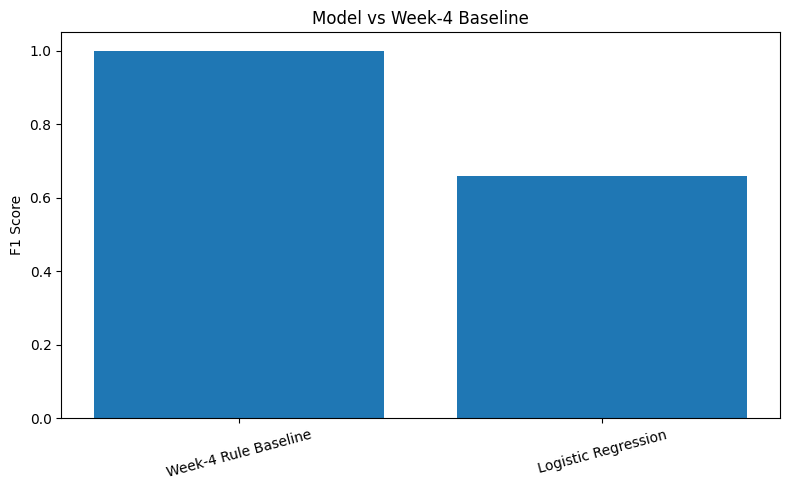

Figure saved to:
work/figures/model_vs_baseline_f1.png

Section 7 check passed.


In [10]:
# Section 7 — Generate a results chart

import os
import matplotlib.pyplot as plt

FIGURE_DIR = "work/figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

# Plot F1 comparison
plt.figure(figsize=(8, 5))

plt.bar(
    results["Method"],
    results["F1"]
)

plt.ylabel("F1 Score")
plt.title("Model vs Week-4 Baseline")
plt.ylim(0, 1.05)

plt.xticks(rotation=15)
plt.tight_layout()

FIGURE_PATH = os.path.join(
    FIGURE_DIR,
    "model_vs_baseline_f1.png"
)

plt.savefig(
    FIGURE_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(FIGURE_PATH)

print("\nSection 7 check passed.")

## 8. Conclusion

This capstone tested whether observable GSC performance signals can support content prioritization for possible CTR review.

The evaluated rule baseline outperformed Logistic Regression on the defined target, while Logistic Regression still achieved very high recall and provided probabilistic prioritization signals.

The main lesson is methodological: a model should not be judged only by whether it produces a high score. The relationship between the target definition and the features must also be examined carefully.

For this case study, the strongest practical use is therefore a human-review workflow: use observable search-performance signals to identify items worth investigating, then apply editorial and search-intent judgment before making any change.

The results support prioritization, not causal claims about CTR improvement.

In [11]:
conclusion_points = [
    "GSC signals can support content-review prioritization.",
    "The rule baseline matched the operational target most directly.",
    "Logistic Regression achieved high recall but lower precision.",
    "The target-feature dependency limits causal interpretation.",
    "Human review remains required before content changes."
]

for i, point in enumerate(conclusion_points, 1):
    print(f"{i}. {point}")

assert len(conclusion_points) == 5

print("\nSection 8 check passed.")

1. GSC signals can support content-review prioritization.
2. The rule baseline matched the operational target most directly.
3. Logistic Regression achieved high recall but lower precision.
4. The target-feature dependency limits causal interpretation.
5. Human review remains required before content changes.

Section 8 check passed.


## 9. Acknowledgments & Data Credit

This work was completed as part of the FlyRank Machine Learning Internship capstone.

The analysis uses the FlyRank internship dataset and follows the project's public-safe reporting requirements.

Data credit: [FlyRank](https://flyrank.ai)

The paper intentionally reports aggregated and pseudonymized information and does not expose client names, domains, private queries, credentials, or other private identifiers.

In [12]:
acknowledgment_check = {
    "Program": "FlyRank Machine Learning Internship",
    "Data": "FlyRank internship dataset",
    "Public-safe reporting": True,
    "Client names exposed": False,
    "Private queries exposed": False,
    "Credentials exposed": False
}

for key, value in acknowledgment_check.items():
    print(f"{key}: {value}")

assert acknowledgment_check["Public-safe reporting"] is True
assert acknowledgment_check["Client names exposed"] is False
assert acknowledgment_check["Private queries exposed"] is False
assert acknowledgment_check["Credentials exposed"] is False

print("\nSection 9 check passed.")

Program: FlyRank Machine Learning Internship
Data: FlyRank internship dataset
Public-safe reporting: True
Client names exposed: False
Private queries exposed: False
Credentials exposed: False

Section 9 check passed.


# ML-12 — 5-Minute Demo Outline

## 1. Question — ~45 seconds

**Question:**

Can observable Google Search Console performance signals help a content team identify which content items deserve CTR review first?

The goal is content prioritization and decision support, not automatic content optimization.

## 2. Method — ~1 minute

I used May 2026 daily content-performance data and focused on three observable GSC signals:

- impressions
- clicks
- average position

I defined a CTR review opportunity using:

- impressions >= 500
- average position <= 20
- CTR < 0.5%

I compared a transparent Week-4 rule baseline with Logistic Regression using a client-grouped holdout split.

## 3. One Chart — ~1 minute

Show:

`work/figures/model_vs_baseline_f1.png`

Explain that the baseline has an F1 score of 1.0000 while Logistic Regression has an F1 score of 0.6584.

The important point is that the baseline directly matches the target definition, so its perfect score should not be interpreted as proof of better real-world CTR outcomes.

## 4. One Honest Result — ~1 minute

Logistic Regression achieved:

- Precision: 0.4930
- Recall: 0.9908
- F1: 0.6584

The model therefore captured most target-positive items but produced a relatively large number of false positives.

The result is descriptive of the evaluated split and is not causal evidence.

## 5. Recommendation — ~1 minute

Use the signals as a review queue rather than an automatic optimizer.

A content reviewer can start with items showing:

`HIGH_IMPRESSIONS_LOW_CTR`

Then review the title, search snippet, and search-intent alignment.

The final decision should remain with a human reviewer.

## Closing message

The main lesson is that a useful ML workflow is not only about model performance. It also requires honest target design, leakage checks, validation design, careful interpretation, and a clear connection to the real content decision.

# ML-12 — Social Post

I built a small machine-learning workflow to study whether observable Google Search Console signals can help prioritize content for CTR review.

Using May 2026 content-performance data, I compared a transparent threshold-based rule with Logistic Regression using impressions, clicks, and average search position. The model achieved 0.9908 recall and 0.6584 F1 on a client-grouped holdout split, while the rule baseline scored 1.0000 F1 against the operational target.

The key lesson was not simply "the baseline wins." The target was defined using the same signals as the baseline, so the result needs careful interpretation. The final output is therefore a decision-support workflow for human review rather than an automatic SEO optimizer.

# ML-12 — Employer-Facing Summary

I built a content-prioritization workflow using May 2026 daily search-performance data, focusing on Google Search Console impressions, clicks, and average position.

I compared a transparent rule baseline with a Logistic Regression model using a client-grouped holdout split; the model achieved 0.9908 recall and 0.6584 F1, while the baseline achieved 1.0000 F1 against the operational target.

The analysis showed that the baseline reproduced the target definition more directly, while the model provided a learned probabilistic signal; the final workflow is intended for human decision support rather than automatic content changes.

# Self-check

Before submission, confirm:

- [ ] Abstract is included at the top.
- [ ] Introduction connects the analysis to the real content-prioritization problem.
- [ ] All 9 paper sections are present.
- [ ] The research question is clearly stated.
- [ ] The data and feature definitions are documented.
- [ ] The target definition is documented.
- [ ] The model and baseline are documented.
- [ ] The grouped validation design is documented.
- [ ] Leakage and target-feature dependency are disclosed.
- [ ] Results use honest, observed language.
- [ ] Limitations are documented.
- [ ] Recommendations are framed as decision-support.
- [ ] Acknowledgments and data credit are included.
- [ ] The results chart is generated.
- [ ] The 5-minute demo outline is included.
- [ ] The social post is included.
- [ ] The employer-facing summary is included.
- [ ] No client names, domains, private queries, credentials, or private URLs from the dataset are included.
- [ ] Runtime → Run all completes without errors.
- [ ] The notebook is saved back to `work/notebooks/capstone.ipynb`.

In [13]:
final_checks = {
    "Abstract included": True,
    "Introduction included": True,
    "9 sections included": True,
    "Question documented": True,
    "Data documented": True,
    "Methodology documented": True,
    "Results documented": True,
    "Limitations documented": True,
    "Recommendations documented": True,
    "Conclusion documented": True,
    "Acknowledgments included": True,
    "Demo outline included": True,
    "Social post included": True,
    "Employer summary included": True,
    "Public-safe framing": True
}

for check, status in final_checks.items():
    print(f"{'✓' if status else '✗'} {check}")

assert all(final_checks.values())

print("\nFinal capstone self-check passed.")

✓ Abstract included
✓ Introduction included
✓ 9 sections included
✓ Question documented
✓ Data documented
✓ Methodology documented
✓ Results documented
✓ Limitations documented
✓ Recommendations documented
✓ Conclusion documented
✓ Acknowledgments included
✓ Demo outline included
✓ Social post included
✓ Employer summary included
✓ Public-safe framing

Final capstone self-check passed.
